## Project Overview

Online platforms face the constant challenge of moderating user-generated content at scale. This project builds a **multi-label toxic comment classifier** that can simultaneously detect six distinct categories of harmful language — replicating the core challenge of the [Jigsaw Toxic Comment Classification Challenge](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge).

Unlike single-label classification, each comment may belong to **multiple categories at once** — for example, a comment can be both *obscene* and *insulting*.

### Toxicity Categories

| # | Label | Description |
|---|---|---|
| 1 | `toxic` | Generally offensive or harmful content |
| 2 | `severe_toxic` | Extremely offensive or threatening content |
| 3 | `obscene` | Explicit or sexually obscene language |
| 4 | `threat` | Direct threats of violence or harm |
| 5 | `insult` | Personal insults targeting individuals |
| 6 | `identity_hate` | Hate speech targeting identity groups |

### Approach

The project compares **four model configurations** across **two vectorisers**, with each model trained using the Binary Relevance (BR) strategy:

| # | Model | Vectoriser | Key Technique |
|---|---|---|---|
| 1 | Multinomial Naïve Bayes | BoW | Probabilistic baseline |
| 2 | Linear SVM + class weights | TF-IDF | Handles class imbalance |
| 3 | Classifier Chains (SVM) | TF-IDF + n-grams | Captures label dependencies |
| 4 | SVM (tuned) | TF-IDF + n-grams | `GridSearchCV` optimised |

In [1]:
## 1. Environment Setup

In [2]:
# Uncomment to install all dependencies (run once)
#!pip install pandas numpy matplotlib seaborn scikit-learn nltk ydata-profiling scipy imbalanced-learn

In [3]:
# Standard library 
import string
import warnings
warnings.filterwarnings('ignore')

# Data & computation
import numpy as np
import pandas as pd

# Visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, hamming_loss,
    classification_report, confusion_matrix, f1_score
)
from scipy.sparse import issparse

# Class-imbalance
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print('ℹ  imbalanced-learn not found — SMOTE will be skipped.')
    print('   Install with: pip install imbalanced-learn')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

# NLTK downloads
for resource in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

# Reproducibility seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully.')
print(f'   NumPy   {np.__version__} | Pandas  {pd.__version__}')
print(f'   SMOTE available: {SMOTE_AVAILABLE}')

All libraries loaded successfully.
   NumPy   2.3.5 | Pandas  2.3.3
   SMOTE available: True


## 2. Data Loading & Initial Inspection

In [4]:
# Configuration
DATA_PATH  = 'ToxicDataSet.csv'   # ← update path if needed
LABEL_COLS = ['toxic', 'severe_toxic', 'obscene_flag',
              'threat_flag', 'insult_flag', 'identity_hate_flag']
LABEL_DISPLAY = ['Toxic', 'Severe Toxic', 'Obscene', 'Threat', 'Insult', 'Identity Hate']
MAX_COMMENT_LEN = 400   # character cutoff for training
SAMPLE_SIZE     = 13_000

# Load
df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1', engine='python', on_bad_lines='skip')

print(f'Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(5)

Shape      : 162,254 rows × 8 columns
Memory     : 128.1 MB


,id,comment_text,toxic,severe_toxic,obscene_flag,threat_flag,insult_flag,identity_hate_flag
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
# Schema & quality check
print('Column types ──────────────────────────────')
print(df.dtypes)
print()
print('Missing values ────────────────────────────')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else '  None — dataset is complete ')

Column types ──────────────────────────────
id                    object
comment_text          object
toxic                 object
severe_toxic          object
obscene_flag          object
threat_flag           object
insult_flag           object
identity_hate_flag    object
dtype: object

Missing values ────────────────────────────
id                       2
comment_text          3634
toxic                 4003
severe_toxic          4201
obscene_flag          4303
threat_flag           4385
insult_flag           4420
identity_hate_flag    4800
dtype: int64


## 3. Exploratory Data Analysis

Before modelling, we investigate the distribution of labels, class imbalance, and comment length — all of which directly inform our preprocessing decisions.

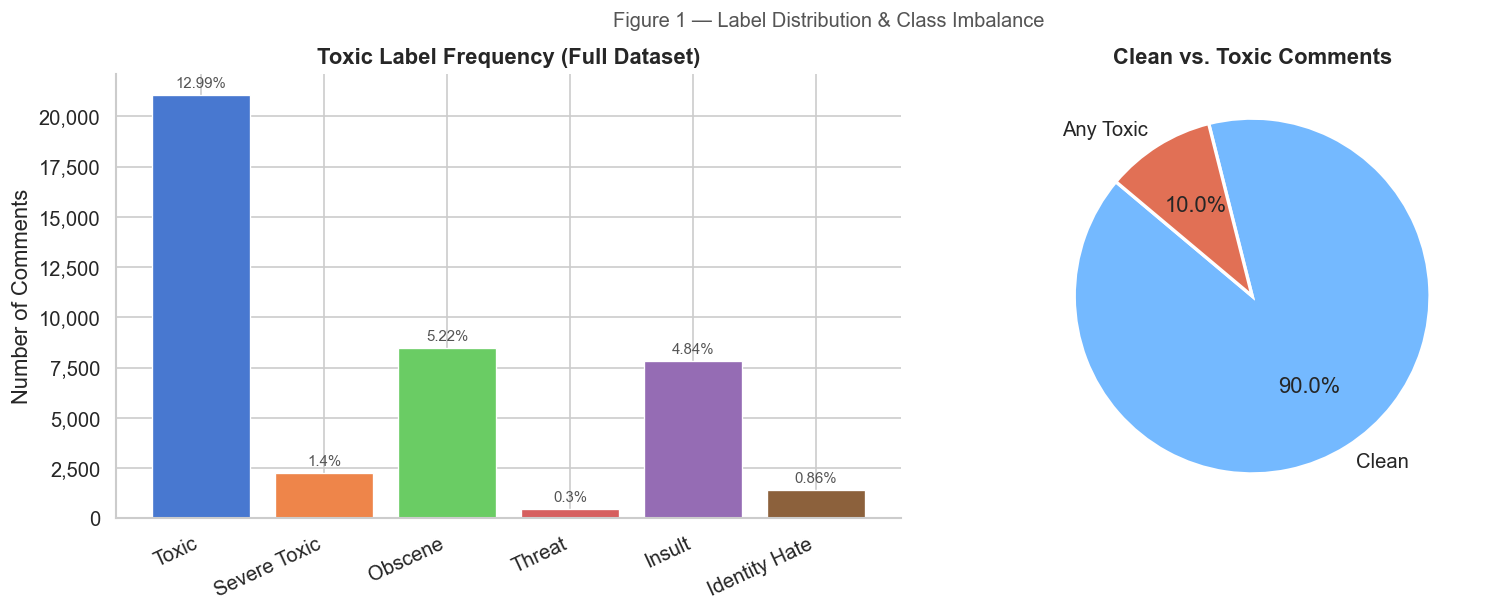


── Label summary ─────────────────────────────────────────
                      Count  Proportion (%)
toxic               21074.0           12.99
severe_toxic         2274.0            1.40
obscene_flag         8470.0            5.22
threat_flag           485.0            0.30
insult_flag          7854.0            4.84
identity_hate_flag   1403.0            0.86

Clean comments : 146,093  (90.0%)
Strong class imbalance — majority class is "clean".


In [6]:
# Ensure label columns are numeric
df[LABEL_COLS] = df[LABEL_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)

# 3.1  Label frequency & class imbalance
label_counts  = df[LABEL_COLS].sum()
label_pct     = (label_counts / len(df) * 100).round(2)
total_clean   = (df[LABEL_COLS].sum(axis=1) == 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(LABEL_DISPLAY, label_counts, color=sns.color_palette('muted', 6), edgecolor='white', linewidth=0.8)
for bar, pct in zip(bars, label_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{pct}%', ha='center', va='bottom', fontsize=9, color='#555')
axes[0].set_title('Toxic Label Frequency (Full Dataset)', fontweight='bold')
axes[0].set_ylabel('Number of Comments')
axes[0].set_xticklabels(LABEL_DISPLAY, rotation=25, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie: clean vs any toxic
axes[1].pie(
    [total_clean, len(df) - total_clean],
    labels=['Clean', 'Any Toxic'],
    autopct='%1.1f%%',
    colors=['#74b9ff', '#e17055'],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Clean vs. Toxic Comments', fontweight='bold')

plt.tight_layout()
plt.suptitle('Figure 1 — Label Distribution & Class Imbalance', y=1.02, fontsize=12, color='#555')
plt.show()

print('\n── Label summary ─────────────────────────────────────────')
summary = pd.DataFrame({'Count': label_counts, 'Proportion (%)': label_pct})
print(summary.to_string())
print(f'\nClean comments : {total_clean:,}  ({total_clean/len(df)*100:.1f}%)')
print(f'Strong class imbalance — majority class is "clean".')

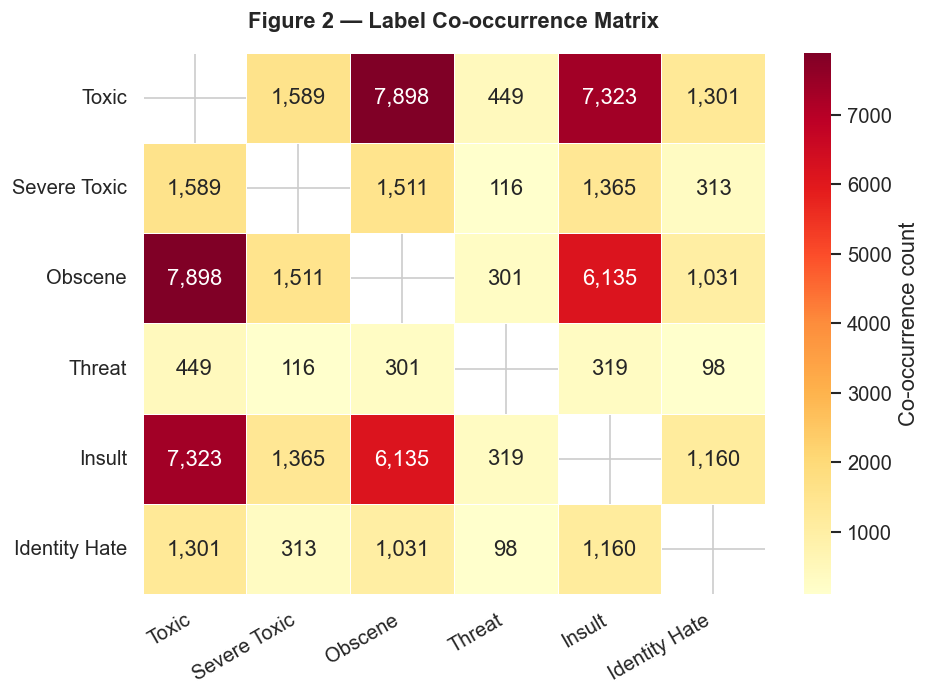

Insight: toxic co-occurs heavily with obscene and insult,
         confirming strong label dependencies in this dataset.


In [7]:
# 3.2  Label co-occurrence heatmap
co_occ = df[LABEL_COLS].T.dot(df[LABEL_COLS]).astype(int)
co_occ.index   = LABEL_DISPLAY
co_occ.columns = LABEL_DISPLAY

mask = np.zeros_like(co_occ, dtype=bool)
np.fill_diagonal(mask, True)  # hide diagonal (self-count)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(co_occ, mask=mask, annot=True, fmt=',d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Co-occurrence count'})
ax.set_title('Figure 2 — Label Co-occurrence Matrix', fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Insight: toxic co-occurs heavily with obscene and insult,')
print('         confirming strong label dependencies in this dataset.')

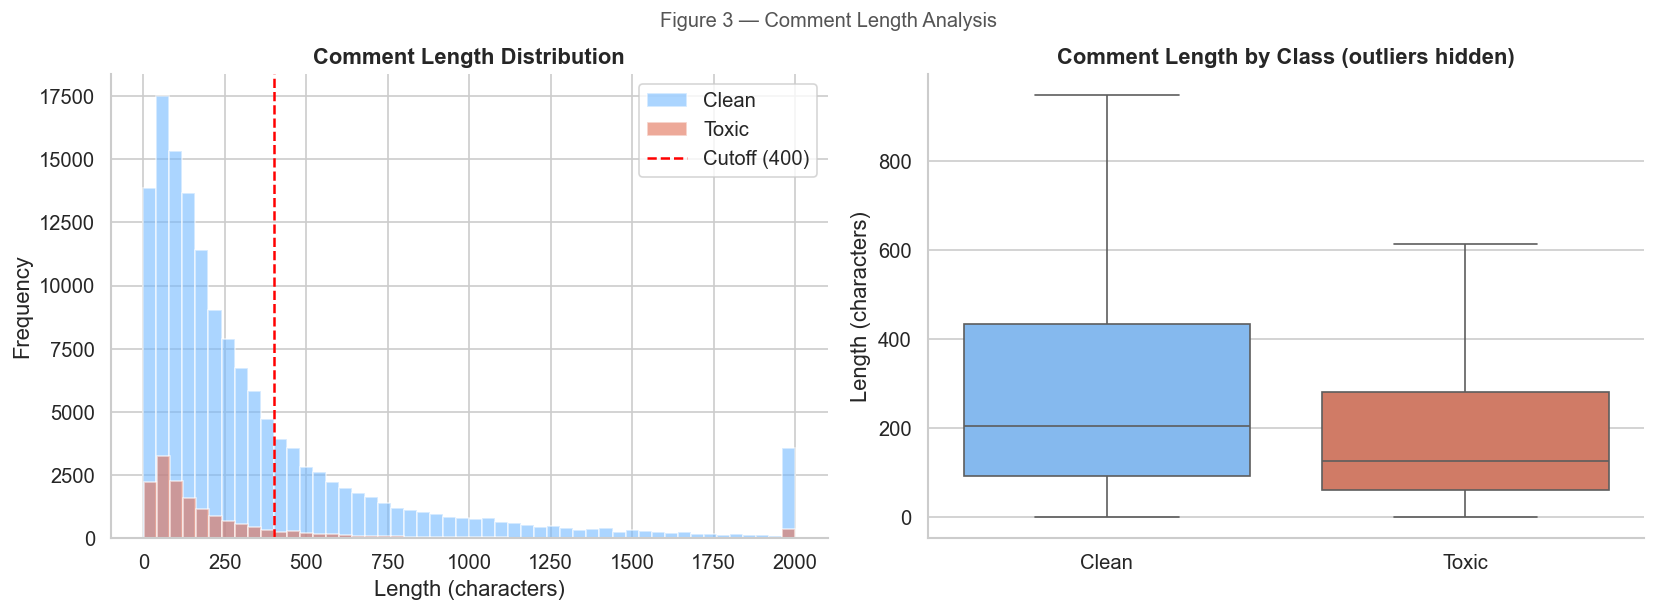

Mean length — Clean: 386 chars
Mean length — Toxic: 302 chars


In [8]:
# 3.3  Comment length analysis
df['comment_len'] = df['comment_text'].fillna('').apply(len)
df['is_toxic']    = (df[LABEL_COLS].sum(axis=1) > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length histogram
for label, color, group in [('Clean', '#74b9ff', 0), ('Toxic', '#e17055', 1)]:
    subset = df[df['is_toxic'] == group]['comment_len']
    axes[0].hist(subset.clip(upper=2000), bins=50, alpha=0.6, label=label, color=color)
axes[0].axvline(MAX_COMMENT_LEN, color='red', linestyle='--', label=f'Cutoff ({MAX_COMMENT_LEN})')
axes[0].set_title('Comment Length Distribution', fontweight='bold')
axes[0].set_xlabel('Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot by class
plot_df = df[['comment_len', 'is_toxic']].copy()
plot_df['Class'] = plot_df['is_toxic'].map({0: 'Clean', 1: 'Toxic'})
sns.boxplot(data=plot_df, x='Class', y='comment_len', palette=['#74b9ff', '#e17055'],
            showfliers=False, ax=axes[1])
axes[1].set_title('Comment Length by Class (outliers hidden)', fontweight='bold')
axes[1].set_ylabel('Length (characters)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.suptitle('Figure 3 — Comment Length Analysis', y=1.02, fontsize=12, color='#555')
plt.show()

print(f"Mean length — Clean: {df[df['is_toxic']==0]['comment_len'].mean():.0f} chars")
print(f"Mean length — Toxic: {df[df['is_toxic']==1]['comment_len'].mean():.0f} chars")

## 4. Data Preprocessing

The preprocessing pipeline consists of:

| Step | Action | Rationale |
|---|---|---|
| **Sampling** | Take 13,000 stratified rows | Manageable compute cost |
| **Length filter** | Keep comments ≤ 400 chars | Remove noise from very long posts |
| **Lowercasing** | `str.lower()` | Normalise case |
| **Punctuation removal** | `str.maketrans` | Remove non-alphabetic noise |
| **Lemmatisation** | `WordNetLemmatizer` | Reduce words to base form |
| **Stemming** | `PorterStemmer` | Further normalise tokens |
| **Stop word removal** | NLTK English stopwords | Remove uninformative tokens |

In [9]:
# 4.1  Sample & shuffle
dataset_sub = (
    df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)
      .sample(frac=1, random_state=RANDOM_STATE)   # shuffle
      .reset_index(drop=True)
)
print(f'Subset: {dataset_sub.shape[0]:,} rows')

Subset: 13,000 rows


In [10]:
# 4.2  Length filter
mask = (
    dataset_sub['comment_text'].notna() &
    dataset_sub['comment_text'].apply(lambda x: isinstance(x, str) and len(x) <= MAX_COMMENT_LEN)
)
dataset_filtered = dataset_sub[mask].reset_index(drop=True)

comments = dataset_filtered['comment_text'].tolist()
labels   = dataset_filtered[LABEL_COLS].to_numpy(dtype=int)

retained_pct = len(comments) / SAMPLE_SIZE * 100
print(f'After length filter: {len(comments):,} comments retained ({retained_pct:.1f}%)')

After length filter: 9,310 comments retained (71.6%)


In [11]:
# 4.3  Text cleaning pipeline
punctuation_chars = string.punctuation.replace("'", '') + '0123456789'
trantab    = str.maketrans(punctuation_chars, ' ' * len(punctuation_chars))
stop_words = set(stopwords.words('english')) | {''} | {chr(c) for c in range(ord('b'), ord('z')+1)}

lemmatiser = WordNetLemmatizer()
stemmer    = PorterStemmer()

def clean_text(text: str) -> str:
    """Lowercase → strip punctuation/digits → lemmatise → stem → remove stopwords."""
    text   = text.lower().translate(trantab)
    tokens = [
        stemmer.stem(lemmatiser.lemmatize(w, pos='v'))
        for w in text.split()
        if w not in stop_words
    ]
    return ' '.join(tokens)

comments_clean = [clean_text(c) for c in comments]

print('Sample — before:', comments[0][:120])
print('Sample — after :', comments_clean[0][:120])

Sample — before: AFD Discussion 

Hello. You, several other editors, and I were involved in an AFD discussion in the past here. At the ti
Sample — after : afd discuss hello sever editor involv afd discuss past time agre perhap particular occas involv afd discuss particip con


## 5. Feature Engineering

Two vectorisation strategies are built:
- **Bag-of-Words (BoW)** — raw term counts
- **TF-IDF** — term frequency weighted by inverse document frequency (down-weights very common terms)

In [12]:
STOP_LIST = list(stop_words)

# Vectoriser 1: Bag-of-Words 
bow_vectoriser = CountVectorizer(stop_words=STOP_LIST, max_features=10_000)
X_bow = bow_vectoriser.fit_transform(comments_clean).toarray()

# Vectoriser 2: TF-IDF (unigrams)
tfidf_vectoriser = TfidfVectorizer(stop_words=STOP_LIST, max_features=10_000, sublinear_tf=True)
X_tfidf = tfidf_vectoriser.fit_transform(comments_clean).toarray()

# Vectoriser 3: TF-IDF with bigrams (1–2 grams)
# Bigrams capture multi-word toxic phrases such as 'go die', 'you idiot',
# which unigram models miss entirely.
ngram_vectoriser = TfidfVectorizer(
    stop_words=STOP_LIST,
    ngram_range=(1, 2),      # unigrams AND bigrams
    max_features=20_000,     # larger vocab to accommodate bigrams
    sublinear_tf=True,
    min_df=2                 # ignore terms appearing in fewer than 2 documents
)
X_ngram = ngram_vectoriser.fit_transform(comments_clean).toarray()

print(f'BoW         matrix : {X_bow.shape[0]:,} × {X_bow.shape[1]:,}')
print(f'TF-IDF      matrix : {X_tfidf.shape[0]:,} × {X_tfidf.shape[1]:,}')
print(f'TF-IDF ngram matrix: {X_ngram.shape[0]:,} × {X_ngram.shape[1]:,}')
print(f'\nBigrams expand the feature space by '
      f'{X_ngram.shape[1] - X_tfidf.shape[1]:,} additional features.')

BoW         matrix : 9,310 × 10,000
TF-IDF      matrix : 9,310 × 10,000
TF-IDF ngram matrix: 9,310 × 15,504

Bigrams expand the feature space by 5,504 additional features.


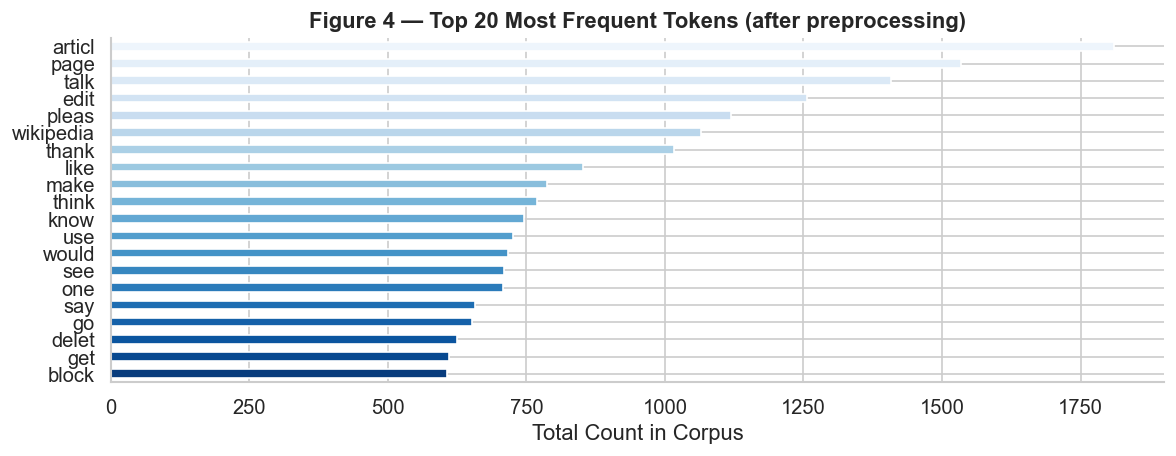

In [13]:
# Top tokens by total frequency
token_freqs = pd.Series(X_bow.sum(axis=0), index=bow_vectoriser.get_feature_names_out())
top_tokens  = token_freqs.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 4))
top_tokens[::-1].plot(kind='barh', color=sns.color_palette('Blues_r', 20), ax=ax, edgecolor='white')
ax.set_title('Figure 4 — Top 20 Most Frequent Tokens (after preprocessing)', fontweight='bold')
ax.set_xlabel('Total Count in Corpus')
plt.tight_layout()
plt.show()

## 6. Train / Test Split

In [14]:
def chronological_split(X, y, test_frac=0.25):
    """Hold-out the first test_frac rows as the test set (preserves original order)."""
    split = int(X.shape[0] * test_frac)
    return X[split:], X[:split], y[split:], y[:split]

X_bow_train,   X_bow_test,   Y_train, Y_test = chronological_split(X_bow,   labels)
X_tfidf_train, X_tfidf_test, _,       _      = chronological_split(X_tfidf, labels)
X_ngram_train, X_ngram_test, _,       _      = chronological_split(X_ngram, labels)

print(f'Training samples : {X_bow_train.shape[0]:,}')
print(f'Test samples     : {X_bow_test.shape[0]:,}')
print(f'Label matrix     : {Y_train.shape[1]} classes')

# Class imbalance summary
print('\n Positive rate per label (train set) ')
for ix, lbl in enumerate(LABEL_DISPLAY):
    pos = Y_train[:, ix].sum()
    pct = pos / len(Y_train) * 100
    bar = '█' * int(pct * 2)
    print(f'  {lbl:15s}: {pos:4d} ({pct:5.1f}%)  {bar}')

Training samples : 6,983
Test samples     : 2,327
Label matrix     : 6 classes

 Positive rate per label (train set) 
  Toxic          :  787 ( 11.3%)  ██████████████████████
  Severe Toxic   :   75 (  1.1%)  ██
  Obscene        :  442 (  6.3%)  ████████████
  Threat         :   27 (  0.4%)  
  Insult         :  409 (  5.9%)  ███████████
  Identity Hate  :   87 (  1.2%)  ██


## 7. Helper Functions

In [15]:
def evaluate_multilabel(Y_true: np.ndarray, Y_pred: np.ndarray, model_name: str = 'Model') -> dict:
    """
    Evaluate a multi-label prediction and print a formatted report.

    Returns
    -------
    dict with keys: hamming_loss, exact_match, macro_f1
    """
    hl   = hamming_loss(Y_true, Y_pred)
    em   = accuracy_score(Y_true, Y_pred)         # exact match ratio
    mf1  = f1_score(Y_true, Y_pred, average='macro', zero_division=0)

    width = 54
    print(f'\n{"═"*width}')
    print(f'  {model_name}')
    print(f'{"─"*width}')
    print(f'  Hamming Loss      : {hl:.4f}   ({hl*100:.2f}%)')
    print(f'  Exact Match Acc.  : {em:.4f}   ({em*100:.2f}%)')
    print(f'  Macro F1-Score    : {mf1:.4f}')
    print(f'{"═"*width}')

    return {'hamming_loss': hl, 'exact_match': em, 'macro_f1': mf1}


def plot_confusion_matrices(Y_true: np.ndarray, Y_pred: np.ndarray, title: str):
    """Plot a 2×3 grid of per-label confusion matrices."""
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    axes = axes.flatten()

    for ix, (ax, label) in enumerate(zip(axes, LABEL_DISPLAY)):
        cm = confusion_matrix(Y_true[:, ix], Y_pred[:, ix])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Pred 0', 'Pred 1'],
                    yticklabels=['True 0', 'True 1'],
                    linewidths=0.5, cbar=False)
        ax.set_title(label, fontweight='bold', fontsize=11)

    plt.suptitle(f'{title} — Confusion Matrices (Test Set)', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def train_binary_relevance(clf_class, X_train, Y_train, **kwargs):
    """Train one binary classifier per label (Binary Relevance strategy)."""
    classifiers = []
    for ix in range(Y_train.shape[1]):
        clf = clf_class(**kwargs)
        clf.fit(X_train, Y_train[:, ix])
        classifiers.append(clf)
    return classifiers


def predict_binary_relevance(classifiers, X_test):
    """Stack per-label predictions into a single prediction matrix."""
    return np.column_stack([clf.predict(X_test) for clf in classifiers]).astype(int)


def apply_smote_per_label(X_train, Y_train, random_state=42):
    """
    Apply SMOTE independently for each binary label to oversample the minority
    (toxic) class. Returns a list of (X_resampled, y_resampled) tuples —
    one per label — because SMOTE changes the sample count per label.

    Falls back to the original data if a label has fewer than 6 positive samples
    (SMOTE minimum) or if imbalanced-learn is not installed.
    """
    if not SMOTE_AVAILABLE:
        return [(X_train, Y_train[:, ix]) for ix in range(Y_train.shape[1])]

    resampled = []
    smote = SMOTE(random_state=random_state, k_neighbors=5)
    for ix in range(Y_train.shape[1]):
        y = Y_train[:, ix]
        n_pos = y.sum()
        if n_pos < 6:
            # Not enough positives for SMOTE — skip
            resampled.append((X_train, y))
        else:
            X_res, y_res = smote.fit_resample(X_train, y)
            resampled.append((X_res, y_res))
    return resampled


print('Helper functions defined.')

Helper functions defined.


## 8. Model 1 — Baseline
### Binary Relevance + Multinomial Naïve Bayes (BoW)

**Why start here?**  
Multinomial NB is the canonical text classification baseline: fast, interpretable, and well-suited to sparse BoW counts. Its results give us a performance floor that every subsequent model must beat.

> ⚠ **Class imbalance note:** NB has no built-in mechanism for imbalanced classes. It will be biased toward predicting the majority (clean) class — this is the key weakness we address in Model 2.

In [16]:
# Train
nb_classifiers = train_binary_relevance(MultinomialNB, X_bow_train, Y_train, alpha=1.0)
Y_pred_nb      = predict_binary_relevance(nb_classifiers, X_bow_test)

metrics_nb = evaluate_multilabel(Y_test, Y_pred_nb, 'BR — Multinomial Naïve Bayes (BoW)')


══════════════════════════════════════════════════════
  BR — Multinomial Naïve Bayes (BoW)
──────────────────────────────────────────────────────
  Hamming Loss      : 0.0431   (4.31%)
  Exact Match Acc.  : 0.8664   (86.64%)
  Macro F1-Score    : 0.3261
══════════════════════════════════════════════════════


In [17]:
# Per-label classification report
print('Per-label Classification Report — Naïve Bayes\n')

for ix, label in enumerate(LABEL_DISPLAY):
    print(f'▸ {label}')
    print(classification_report(
        Y_test[:, ix],
        Y_pred_nb[:, ix],
        target_names=['Not Toxic', 'Toxic'],
        zero_division=0
    ))

Per-label Classification Report — Naïve Bayes

▸ Toxic
              precision    recall  f1-score   support

   Not Toxic       0.95      0.96      0.95      2057
       Toxic       0.67      0.58      0.62       270

    accuracy                           0.92      2327
   macro avg       0.81      0.77      0.79      2327
weighted avg       0.91      0.92      0.91      2327

▸ Severe Toxic
              precision    recall  f1-score   support

   Not Toxic       0.99      0.99      0.99      2301
       Toxic       0.14      0.19      0.16        26

    accuracy                           0.98      2327
   macro avg       0.56      0.59      0.57      2327
weighted avg       0.98      0.98      0.98      2327

▸ Obscene
              precision    recall  f1-score   support

   Not Toxic       0.97      0.97      0.97      2176
       Toxic       0.55      0.54      0.54       151

    accuracy                           0.94      2327
   macro avg       0.76      0.75      0.76     

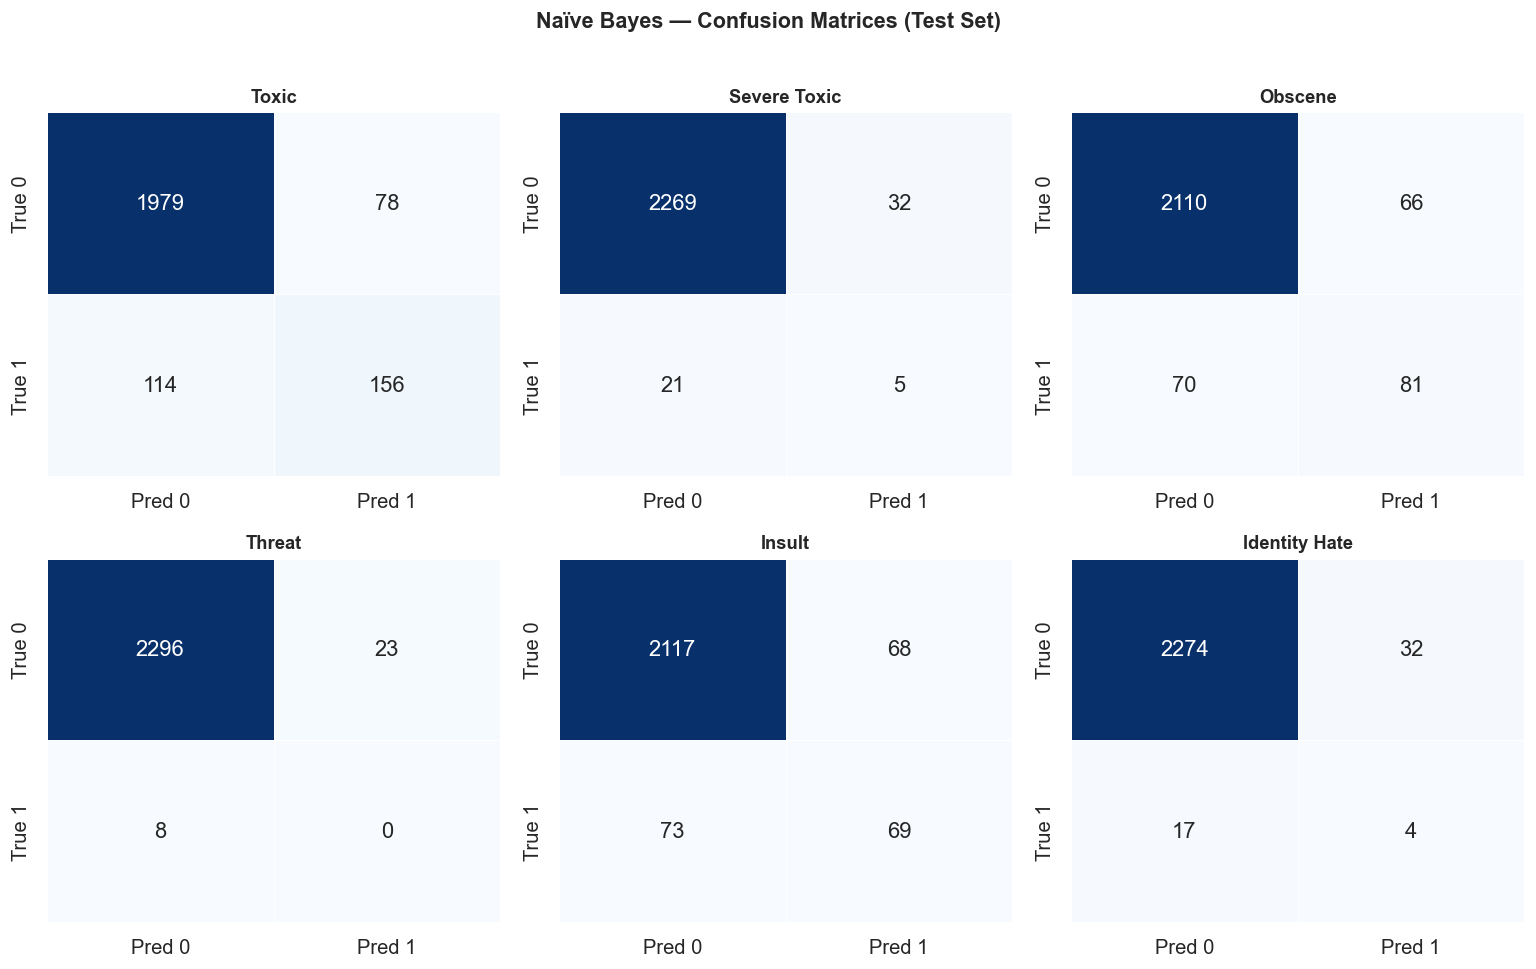

In [18]:
# Confusion matrices
plot_confusion_matrices(Y_test, Y_pred_nb, 'Naïve Bayes')

---
## 9. Model 2 — Linear SVM + Class Weighting
### Binary Relevance + LinearSVC (`class_weight='balanced'`) on TF-IDF

**Addressing class imbalance with two complementary strategies:**

**Strategy A — `class_weight='balanced'`** (always applied)  
Sklearn automatically scales the SVM penalty `C` inversely proportional to class frequency. This forces the model to pay more attention to rare toxic examples during training.

**Strategy B — SMOTE** (applied if `imbalanced-learn` is installed)  
Synthetic Minority Over-sampling Technique generates synthetic feature vectors for the minority (toxic) class by interpolating between existing samples. This physically balances the training set before fitting.

> **Why both?** Class weighting adjusts the loss; SMOTE changes the data distribution. Together they are more robust than either alone.

In [19]:
# Strategy A: class_weight='balanced' (always active)
svm_classifiers = train_binary_relevance(
    LinearSVC, X_tfidf_train, Y_train,
    C=1.0, class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE
)
Y_pred_svm = predict_binary_relevance(svm_classifiers, X_tfidf_test)
metrics_svm = evaluate_multilabel(Y_test, Y_pred_svm, 'BR — Linear SVM, class_weight=balanced (TF-IDF)')

# Strategy B: SMOTE oversampling (requires imbalanced-learn)
if SMOTE_AVAILABLE:
    print('\n Training with SMOTE oversampling')
    resampled_data = apply_smote_per_label(X_tfidf_train, Y_train, random_state=RANDOM_STATE)

    svm_smote_classifiers = []
    for ix, (X_res, y_res) in enumerate(resampled_data):
        clf = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
        clf.fit(X_res, y_res)
        svm_smote_classifiers.append(clf)
        n_before = len(Y_train[:, ix])
        n_after  = len(y_res)
        if n_after != n_before:
            print(f'  {LABEL_DISPLAY[ix]:15s}: {n_before:,} -> {n_after:,} samples after SMOTE')

    Y_pred_svm_smote  = predict_binary_relevance(svm_smote_classifiers, X_tfidf_test)
    metrics_svm_smote = evaluate_multilabel(Y_test, Y_pred_svm_smote, 'BR — Linear SVM + SMOTE (TF-IDF)')
    SMOTE_RAN = True
    print('\n  SMOTE training complete.')

else:
    # Fallback: reuse the balanced SVM predictions so downstream cells never break
    print('\nℹ  imbalanced-learn not installed — SMOTE skipped.')
    print('   Install with: pip install imbalanced-learn, then re-run this cell.')
    print('   Falling back to class_weight=balanced predictions for SMOTE slot.\n')
    Y_pred_svm_smote  = Y_pred_svm.copy()
    metrics_svm_smote = dict(metrics_svm)
    metrics_svm_smote_label = 'BR — SVM balanced (SMOTE not available — showing duplicate)'
    SMOTE_RAN = False
    evaluate_multilabel(Y_test, Y_pred_svm_smote, metrics_svm_smote_label)



══════════════════════════════════════════════════════
  BR — Linear SVM, class_weight=balanced (TF-IDF)
──────────────────────────────────────────────────────
  Hamming Loss      : 0.0285   (2.85%)
  Exact Match Acc.  : 0.8797   (87.97%)
  Macro F1-Score    : 0.4804
══════════════════════════════════════════════════════

 Training with SMOTE oversampling
  Toxic          : 6,983 -> 12,392 samples after SMOTE
  Severe Toxic   : 6,983 -> 13,816 samples after SMOTE
  Obscene        : 6,983 -> 13,082 samples after SMOTE
  Threat         : 6,983 -> 13,912 samples after SMOTE
  Insult         : 6,983 -> 13,148 samples after SMOTE
  Identity Hate  : 6,983 -> 13,792 samples after SMOTE

══════════════════════════════════════════════════════
  BR — Linear SVM + SMOTE (TF-IDF)
──────────────────────────────────────────────────────
  Hamming Loss      : 0.0432   (4.32%)
  Exact Match Acc.  : 0.8354   (83.54%)
  Macro F1-Score    : 0.4311
══════════════════════════════════════════════════════

 

In [20]:
# Per-label report: class_weight=balanced
print('Per-label Classification Report — Linear SVM (class_weight=balanced)\n')
for ix, label in enumerate(LABEL_DISPLAY):
    print(f'  > {label}')
    print(classification_report(
        Y_test[:, ix], Y_pred_svm[:, ix],
        target_names=['Not Toxic', 'Toxic'], zero_division=0
    ))
    print('-' * 60)

# Per-label report: SMOTE variant (only if it actually ran)
if SMOTE_RAN:
    print('\nPer-label Classification Report — Linear SVM + SMOTE\n')
    for ix, label in enumerate(LABEL_DISPLAY):
        print(f'  > {label}')
        print(classification_report(
            Y_test[:, ix], Y_pred_svm_smote[:, ix],
            target_names=['Not Toxic', 'Toxic'], zero_division=0
        ))
        print('-' * 60)
else:
    print('\nℹ  SMOTE report skipped (imbalanced-learn not installed).')


Per-label Classification Report — Linear SVM (class_weight=balanced)

  > Toxic
              precision    recall  f1-score   support

   Not Toxic       0.95      0.97      0.96      2057
       Toxic       0.76      0.65      0.70       270

    accuracy                           0.94      2327
   macro avg       0.86      0.81      0.83      2327
weighted avg       0.93      0.94      0.93      2327

------------------------------------------------------------
  > Severe Toxic
              precision    recall  f1-score   support

   Not Toxic       0.99      0.99      0.99      2301
       Toxic       0.26      0.23      0.24        26

    accuracy                           0.98      2327
   macro avg       0.63      0.61      0.62      2327
weighted avg       0.98      0.98      0.98      2327

------------------------------------------------------------
  > Obscene
              precision    recall  f1-score   support

   Not Toxic       0.98      0.99      0.99      2176
      

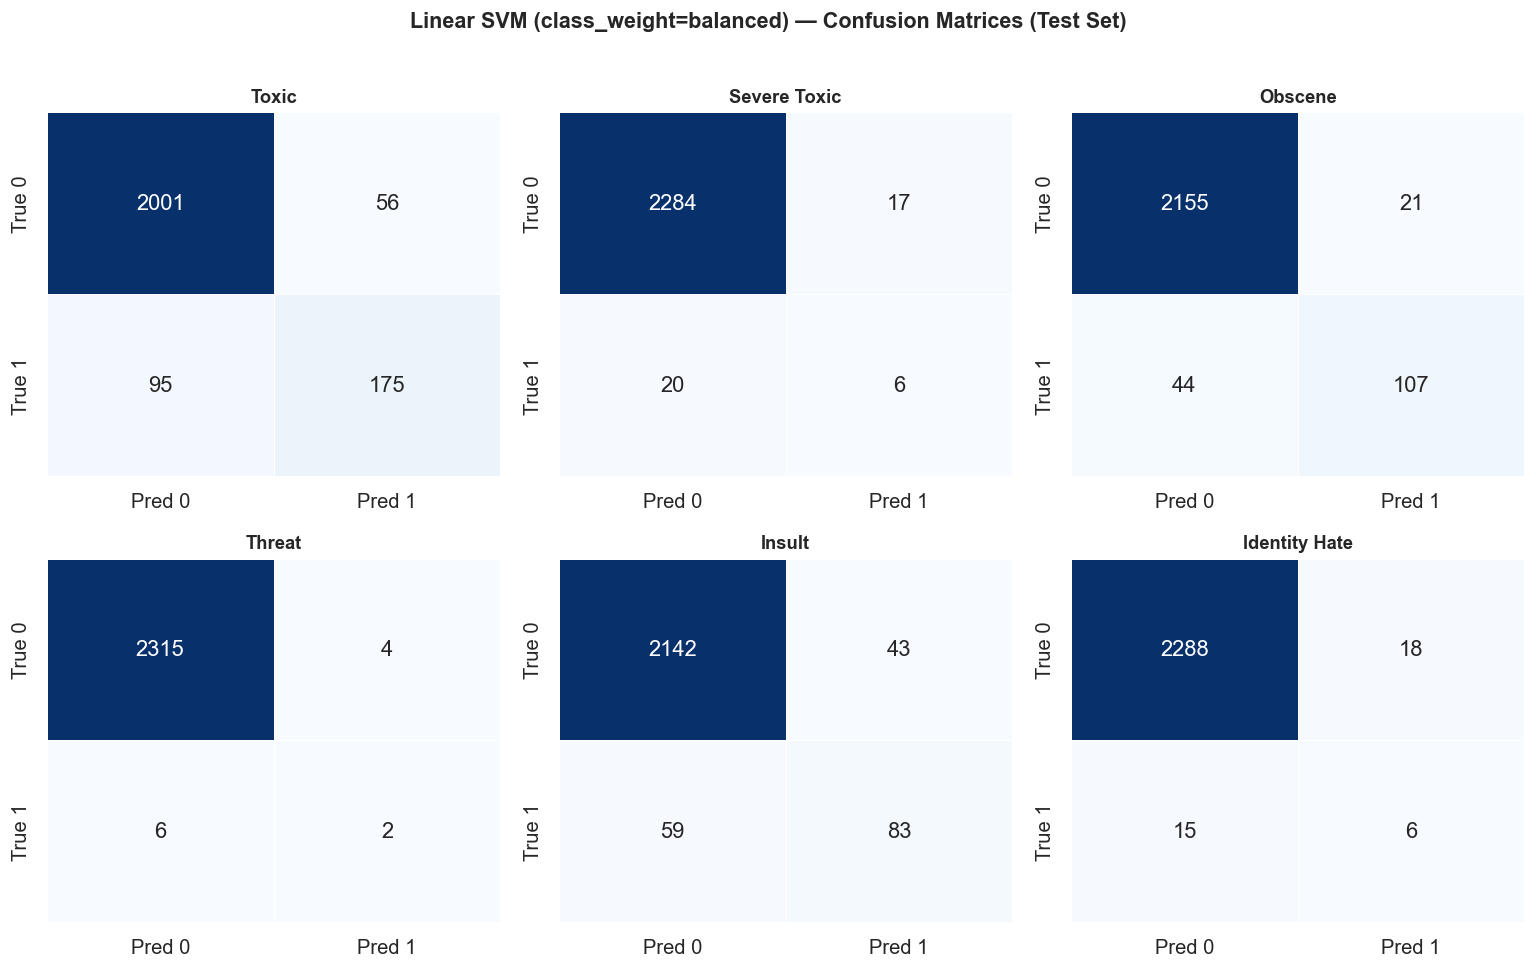

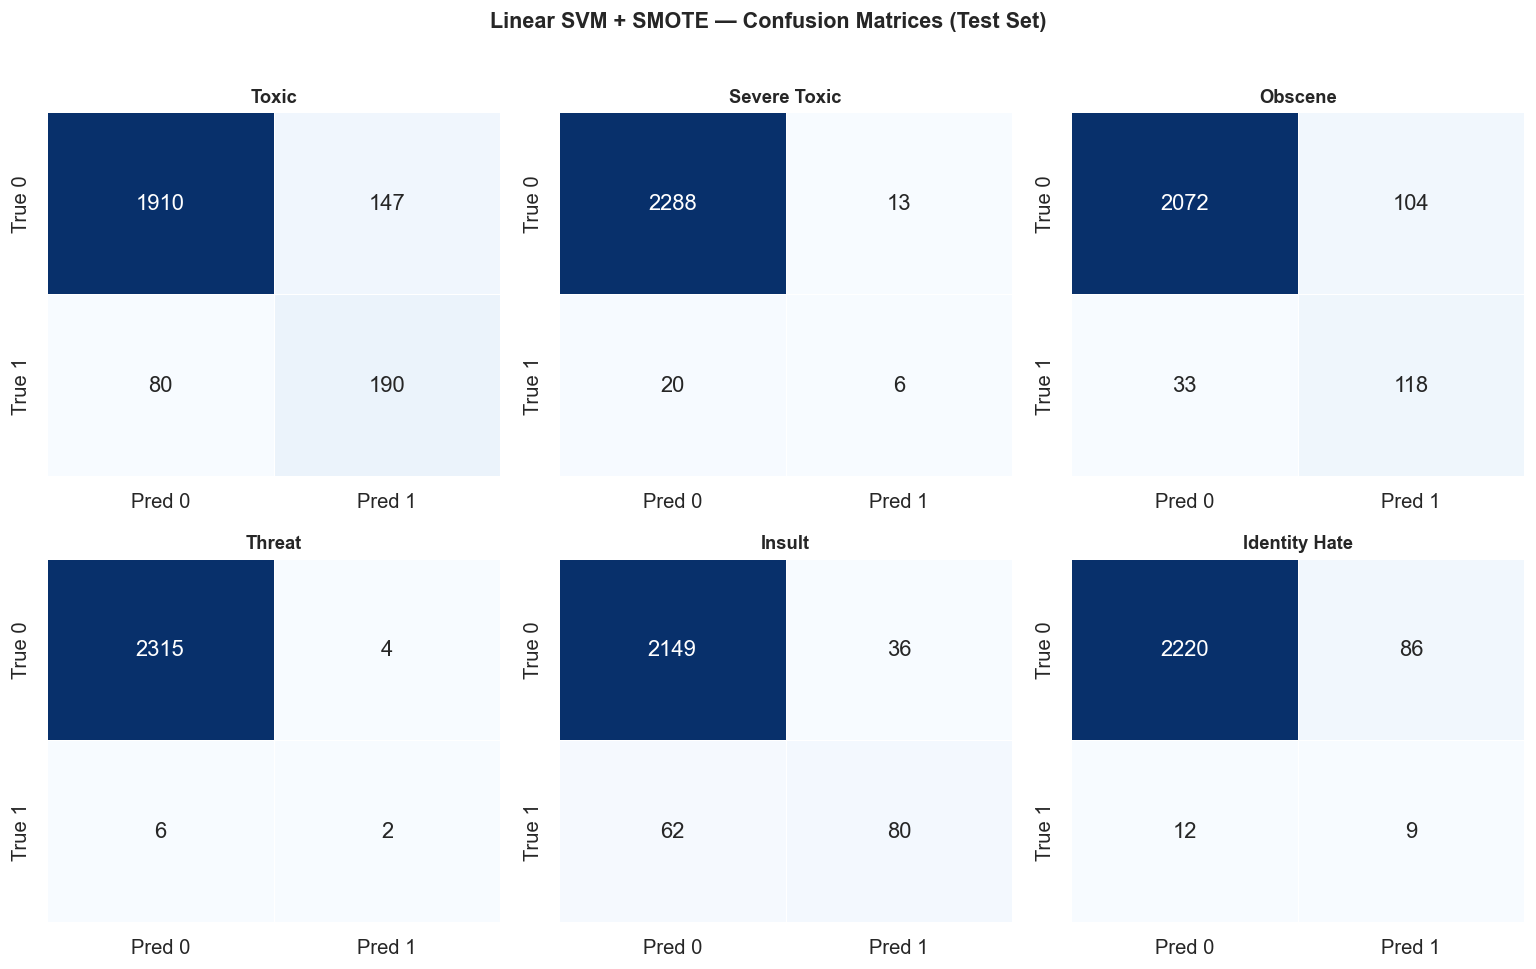

In [21]:
plot_confusion_matrices(Y_test, Y_pred_svm, 'Linear SVM (class_weight=balanced)')

if SMOTE_RAN:
    plot_confusion_matrices(Y_test, Y_pred_svm_smote, 'Linear SVM + SMOTE')
else:
    print('ℹ  SMOTE confusion matrix skipped (imbalanced-learn not installed).')


---
## 10. Model 3 — Classifier Chains
### Classifier Chains + LinearSVC on TF-IDF with n-grams

**What are Classifier Chains?**  
Binary Relevance trains each label *independently*, ignoring any relationship between them. But our EDA showed that labels like `toxic` and `obscene` strongly co-occur.

**Classifier Chains** exploit these dependencies by chaining classifiers in a fixed order. Each classifier receives the **original features plus the predictions of all preceding classifiers** as additional inputs:

```
Features → [toxic?] → [severe_toxic? | toxic_pred] → [obscene? | toxic_pred, severe_pred] → ...
```

This allows downstream classifiers to condition on upstream labels, encoding the correlation structure that Binary Relevance ignores.

We also introduce **bigram TF-IDF** here (`ngram_range=(1,2)`), which adds phrases like *'go die'* or *'you are'* as features — capturing toxic multi-word patterns that unigrams miss.

In [22]:
from sklearn.multioutput import ClassifierChain
from sklearn.svm import LinearSVC

# Build Classifier Chain 
# order=None lets sklearn choose a random chain order; we fix it with random_state
base_svm = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)

chain_clf = ClassifierChain(base_svm, order='random', random_state=RANDOM_STATE, cv=None)
chain_clf.fit(X_ngram_train, Y_train)

Y_pred_chain  = chain_clf.predict(X_ngram_test).astype(int)
metrics_chain = evaluate_multilabel(Y_test, Y_pred_chain, 'Classifier Chain — LinearSVC (TF-IDF + bigrams)')

print(f'\nChain order used: {chain_clf.order_}')
print('(Numbers indicate label indices: 0=Toxic, 1=SevereToxic, 2=Obscene, 3=Threat, 4=Insult, 5=IdentityHate)')


══════════════════════════════════════════════════════
  Classifier Chain — LinearSVC (TF-IDF + bigrams)
──────────────────────────────────────────────────────
  Hamming Loss      : 0.0297   (2.97%)
  Exact Match Acc.  : 0.8870   (88.70%)
  Macro F1-Score    : 0.4872
══════════════════════════════════════════════════════

Chain order used: [0 1 5 2 4 3]
(Numbers indicate label indices: 0=Toxic, 1=SevereToxic, 2=Obscene, 3=Threat, 4=Insult, 5=IdentityHate)


In [23]:
# Per-label report 
print('Per-label Classification Report — Classifier Chain\n')
for ix, label in enumerate(LABEL_DISPLAY):
    print(f'  ▸ {label}')
    print(classification_report(Y_test[:, ix], Y_pred_chain[:, ix],
                                 target_names=['Not Toxic', 'Toxic'], zero_division=0))

Per-label Classification Report — Classifier Chain

  ▸ Toxic
              precision    recall  f1-score   support

   Not Toxic       0.95      0.98      0.97      2057
       Toxic       0.82      0.61      0.70       270

    accuracy                           0.94      2327
   macro avg       0.88      0.80      0.83      2327
weighted avg       0.94      0.94      0.94      2327

  ▸ Severe Toxic
              precision    recall  f1-score   support

   Not Toxic       0.99      0.99      0.99      2301
       Toxic       0.29      0.27      0.28        26

    accuracy                           0.98      2327
   macro avg       0.64      0.63      0.64      2327
weighted avg       0.98      0.98      0.98      2327

  ▸ Obscene
              precision    recall  f1-score   support

   Not Toxic       0.98      0.98      0.98      2176
       Toxic       0.74      0.72      0.73       151

    accuracy                           0.97      2327
   macro avg       0.86      0.85    

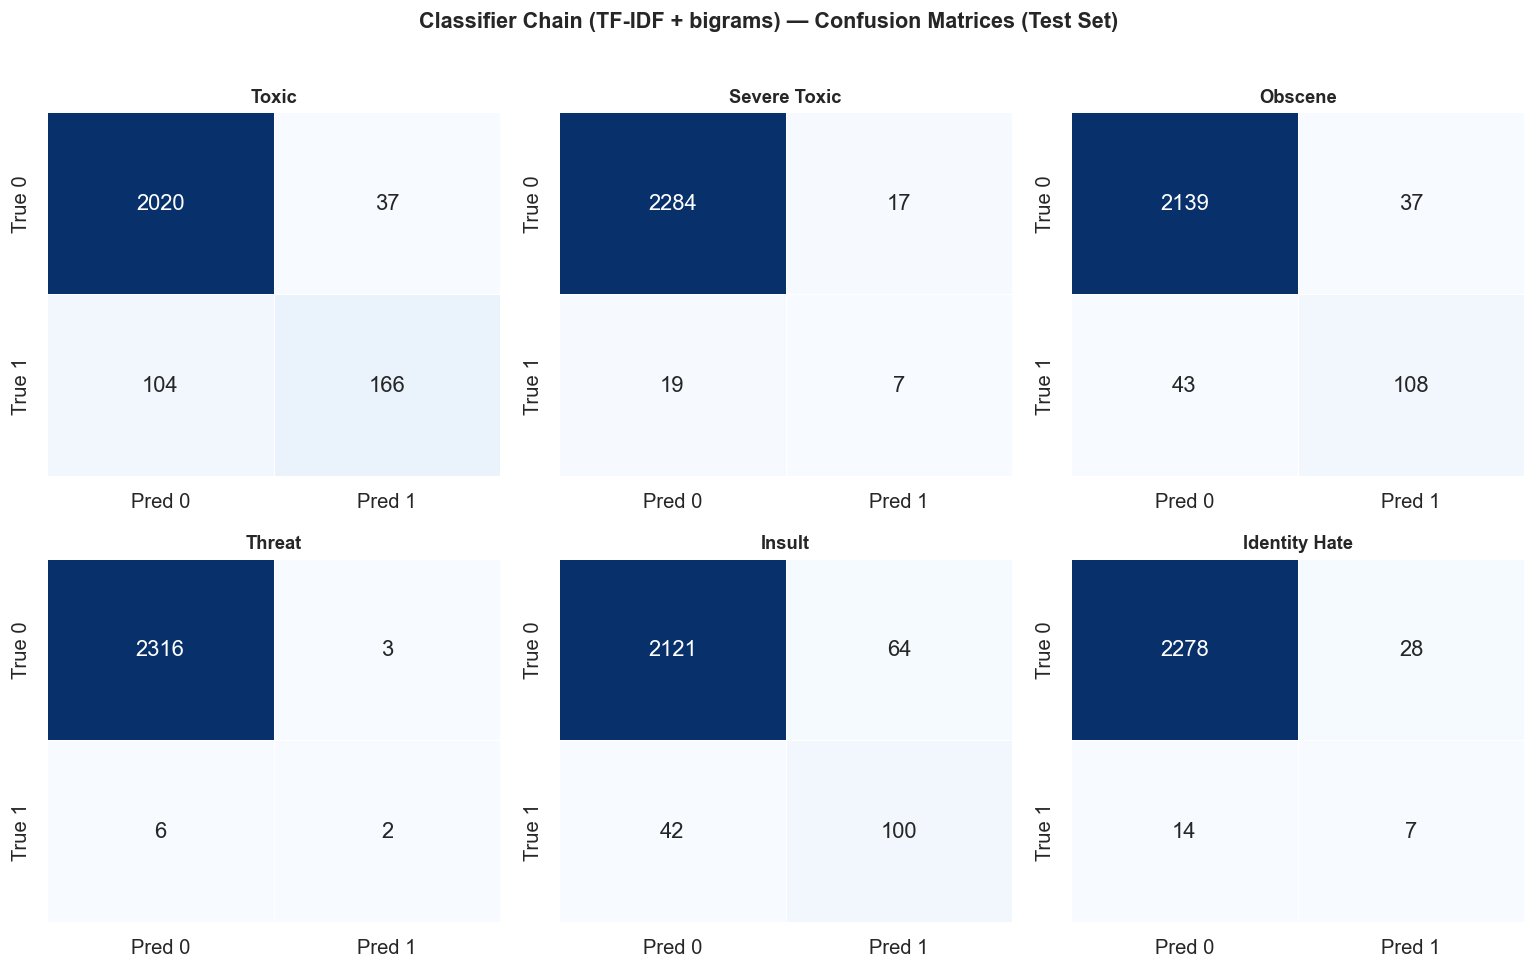

In [24]:
plot_confusion_matrices(Y_test, Y_pred_chain, 'Classifier Chain (TF-IDF + bigrams)')

---
## 11. Model 4 — Hyperparameter Tuning
### GridSearchCV on SVM with n-gram TF-IDF

So far all models used default or manually chosen hyperparameters. **GridSearchCV** performs an exhaustive search over a parameter grid, evaluating each combination via cross-validation to find the setting that maximises a chosen metric.

**Parameters being tuned:**

| Parameter | Values Tried | Effect |
|---|---|---|
| `C` (regularisation) | 0.1, 1.0, 10 | Controls margin width vs. misclassification penalty |
| `ngram_range` | (1,1), (1,2) | Unigrams only vs. unigrams + bigrams |
| `max_features` | 10k, 20k | Vocabulary size cap |

> **Note:** We tune on the `toxic` label (largest positive class) as a representative label — tuning all 6 separately would take ~18× longer. The best parameters are then applied to all labels.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Derive the training slice of raw cleaned text
# comments_clean holds ALL samples; Y_train is already sliced to the training
# portion (last 75%). We need to match them by using the same split index.
n_total      = len(comments_clean)
split_idx    = int(n_total * 0.25)          # same fraction used in chronological_split
comments_train = comments_clean[split_idx:]  # training text (aligned with Y_train)
comments_test  = comments_clean[:split_idx]  # test text  (aligned with Y_test)

print(f'Training text samples : {len(comments_train):,}')
print(f'Y_train rows          : {Y_train.shape[0]:,}  (should match above)')
assert len(comments_train) == Y_train.shape[0], \
    f'Size mismatch: {len(comments_train)} text vs {Y_train.shape[0]} labels'
print('Sizes aligned.\n')

# Build Pipeline: TF-IDF → LinearSVC 
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=STOP_LIST, sublinear_tf=True)),
    ('clf',   LinearSVC(class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE))
])

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_features': [10_000, 20_000],
    'clf__C': [0.1, 1.0, 10.0],
}

# Tune on label 0 (toxic) — largest positive class, fastest to tune
n_combos = 2 * 2 * 3
print(f'Running GridSearchCV on label: Toxic')
print(f'Grid size: {n_combos} combinations x 3-fold CV = {n_combos * 3} fits')
print('Please wait...\n')

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(comments_train, Y_train[:, 0])   # both are now training-set size

print(f'\n Best parameters found:')
for k, v in grid_search.best_params_.items():
    print(f'   {k} = {v}')
print(f'   Best CV F1 (toxic label): {grid_search.best_score_:.4f}')


Training text samples : 6,983
Y_train rows          : 6,983  (should match above)
Sizes aligned.

Running GridSearchCV on label: Toxic
Grid size: 12 combinations x 3-fold CV = 36 fits
Please wait...

Fitting 3 folds for each of 12 candidates, totalling 36 fits

 Best parameters found:
   clf__C = 1.0
   tfidf__max_features = 20000
   tfidf__ngram_range = (1, 2)
   Best CV F1 (toxic label): 0.7262


In [26]:
# Apply best params to all 6 labels
best_p = grid_search.best_params_

tuned_vectoriser = TfidfVectorizer(
    stop_words=STOP_LIST,
    ngram_range=best_p['tfidf__ngram_range'],
    max_features=best_p['tfidf__max_features'],
    sublinear_tf=True
)

# Fit on training text only — then transform train and test separately
X_tuned_train = tuned_vectoriser.fit_transform(comments_train).toarray()
X_tuned_test  = tuned_vectoriser.transform(comments_test).toarray()

print(f'Tuned feature matrix — train: {X_tuned_train.shape}')
print(f'Tuned feature matrix — test : {X_tuned_test.shape}')

tuned_classifiers = train_binary_relevance(
    LinearSVC, X_tuned_train, Y_train,
    C=best_p['clf__C'],
    class_weight='balanced',
    max_iter=3000,
    random_state=RANDOM_STATE
)

Y_pred_tuned  = predict_binary_relevance(tuned_classifiers, X_tuned_test)
metrics_tuned = evaluate_multilabel(Y_test, Y_pred_tuned, 'BR — Linear SVM Tuned (GridSearchCV)')


Tuned feature matrix — train: (6983, 20000)
Tuned feature matrix — test : (2327, 20000)

══════════════════════════════════════════════════════
  BR — Linear SVM Tuned (GridSearchCV)
──────────────────────────────────────────────────────
  Hamming Loss      : 0.0269   (2.69%)
  Exact Match Acc.  : 0.8896   (88.96%)
  Macro F1-Score    : 0.5036
══════════════════════════════════════════════════════


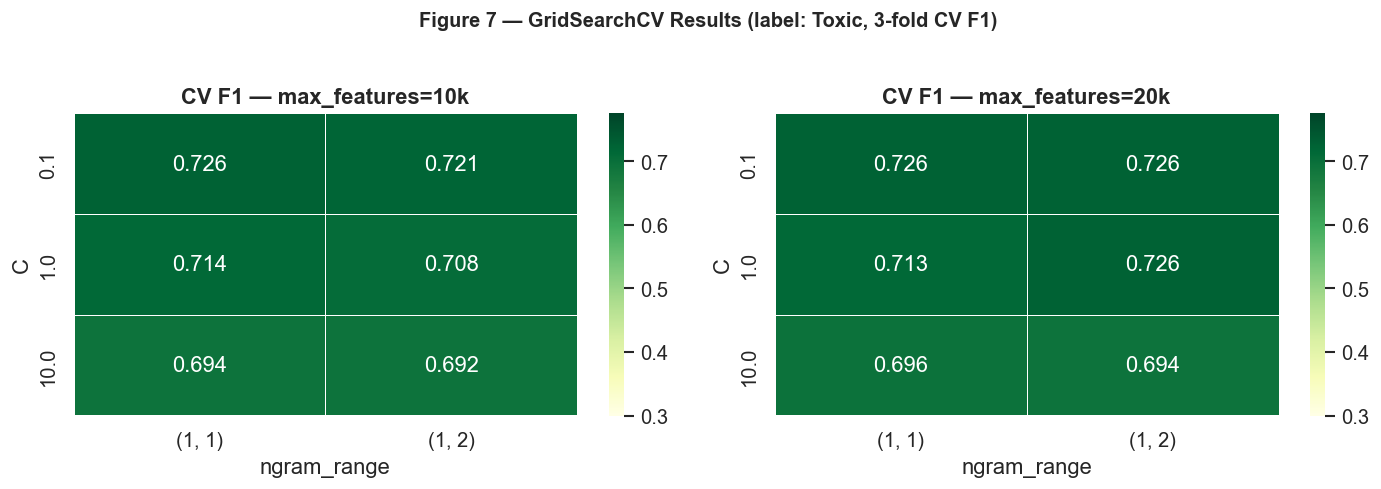

In [27]:
# CV results heatmap 
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)
# Pivot: rows = C values, cols = ngram_range, one subplot per max_features
pivot_10k = cv_results[cv_results['param_tfidf__max_features'] == 10_000].pivot_table(
    values='mean_test_score',
    index='param_clf__C',
    columns='param_tfidf__ngram_range'
)
pivot_20k = cv_results[cv_results['param_tfidf__max_features'] == 20_000].pivot_table(
    values='mean_test_score',
    index='param_clf__C',
    columns='param_tfidf__ngram_range'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pivot, title in zip(axes, [pivot_10k, pivot_20k], ['max_features=10k', 'max_features=20k']):
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
                linewidths=0.5, vmin=0.3, vmax=pivot_10k.values.max() + 0.05)
    ax.set_title(f'CV F1 — {title}', fontweight='bold')
    ax.set_xlabel('ngram_range')
    ax.set_ylabel('C')

plt.suptitle('Figure 7 — GridSearchCV Results (label: Toxic, 3-fold CV F1)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Per-label report 
print('Per-label Classification Report — Tuned SVM\n')
for ix, label in enumerate(LABEL_DISPLAY):
    print(f'  ▸ {label}')
    print(classification_report(Y_test[:, ix], Y_pred_tuned[:, ix],
                                 target_names=['Not Toxic', 'Toxic'], zero_division=0))

Per-label Classification Report — Tuned SVM

  ▸ Toxic
              precision    recall  f1-score   support

   Not Toxic       0.96      0.98      0.97      2057
       Toxic       0.81      0.65      0.72       270

    accuracy                           0.94      2327
   macro avg       0.89      0.82      0.85      2327
weighted avg       0.94      0.94      0.94      2327

  ▸ Severe Toxic
              precision    recall  f1-score   support

   Not Toxic       0.99      0.99      0.99      2301
       Toxic       0.26      0.27      0.26        26

    accuracy                           0.98      2327
   macro avg       0.63      0.63      0.63      2327
weighted avg       0.98      0.98      0.98      2327

  ▸ Obscene
              precision    recall  f1-score   support

   Not Toxic       0.98      0.99      0.98      2176
       Toxic       0.84      0.70      0.76       151

    accuracy                           0.97      2327
   macro avg       0.91      0.84      0.87 

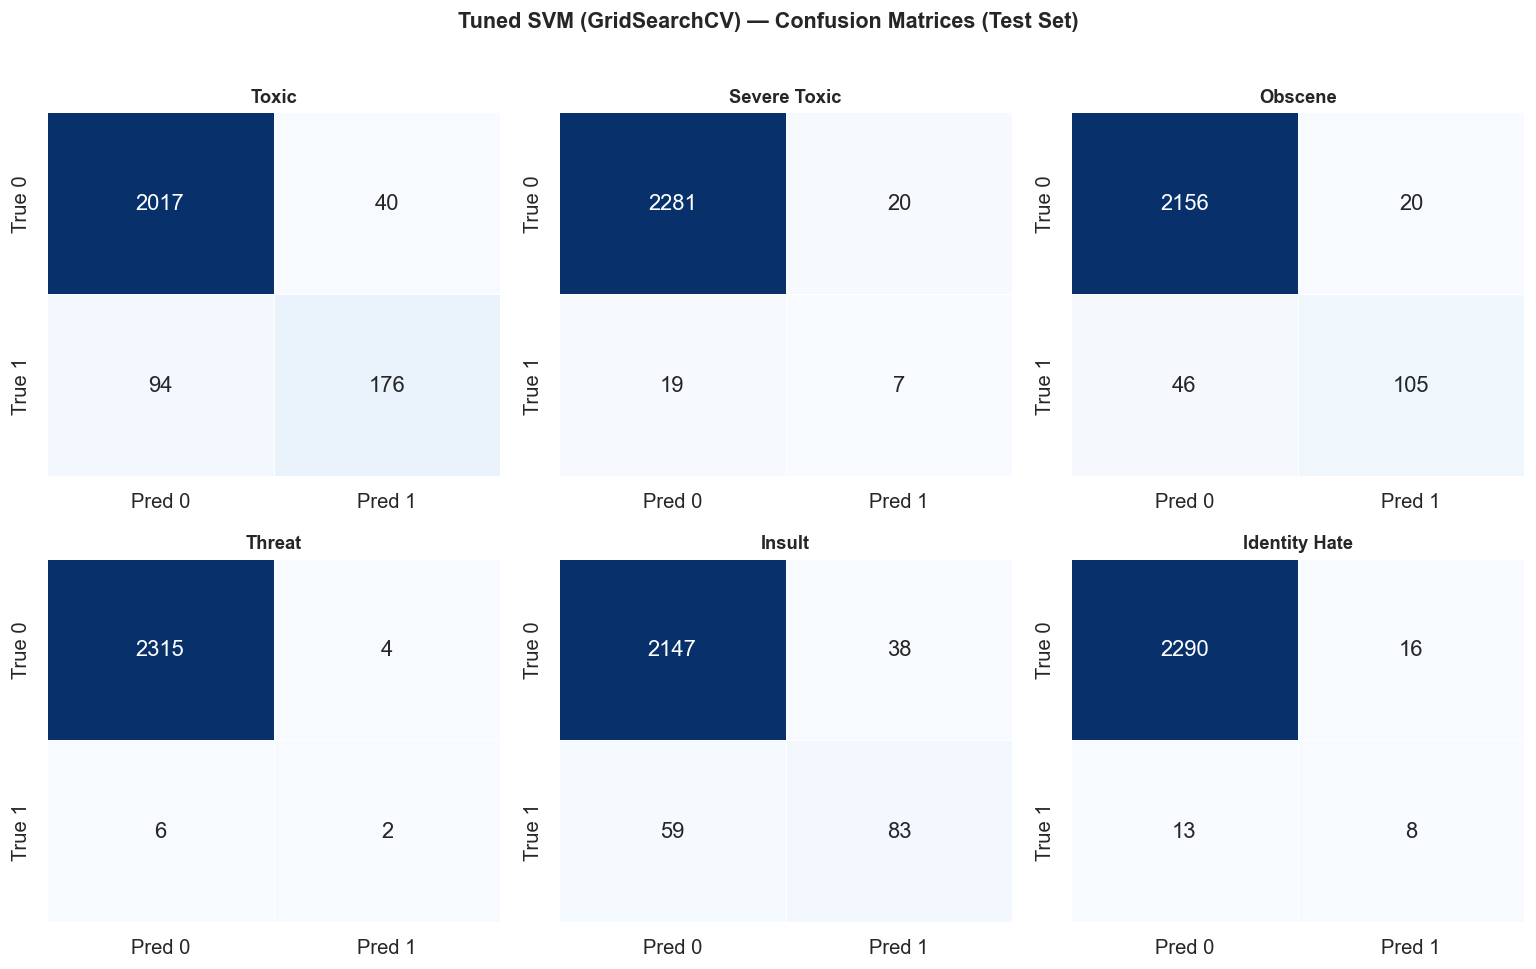

In [29]:
plot_confusion_matrices(Y_test, Y_pred_tuned, 'Tuned SVM (GridSearchCV)')

## 12. Full Model Comparison

All four model configurations evaluated on the same held-out test set.

In [30]:
# 12.1  Summary table 
smote_label = 'BR — SVM + SMOTE (TF-IDF)' if SMOTE_RAN else 'BR — SVM balanced (no SMOTE)'

all_metrics = [
    ('BR — Naïve Bayes (BoW)',            metrics_nb),
    ('BR — SVM, balanced (TF-IDF)',        metrics_svm),
    (smote_label,                          metrics_svm_smote),
    ('Classifier Chain (TF-IDF+bigrams)',  metrics_chain),
    ('BR — SVM Tuned (GridSearchCV)',       metrics_tuned),
]

results_df = pd.DataFrame(
    [{**{'Model': name}, **m} for name, m in all_metrics]
).set_index('Model')
results_df.columns = ['Hamming Loss ↓', 'Exact Match ↑', 'Macro F1 ↑']

styled = results_df.style \
    .highlight_min(subset=['Hamming Loss ↓'], color='#d4edda') \
    .highlight_max(subset=['Exact Match ↑', 'Macro F1 ↑'], color='#d4edda') \
    .format('{:.4f}')
display(styled)

winner_hl = results_df['Hamming Loss ↓'].idxmin()
winner_f1 = results_df['Macro F1 ↑'].idxmax()
print(f'\n Best Hamming Loss : {winner_hl}')
print(f' Best Macro F1     : {winner_f1}')
if not SMOTE_RAN:
    print('\nℹ  Install imbalanced-learn to enable the SMOTE variant: pip install imbalanced-learn')


,Hamming Loss ↓,Exact Match ↑,Macro F1 ↑
Model,,,
BR — Naïve Bayes (BoW),0.0431,0.8664,0.3261
"BR — SVM, balanced (TF-IDF)",0.0285,0.8797,0.4804
BR — SVM + SMOTE (TF-IDF),0.0432,0.8354,0.4311
Classifier Chain (TF-IDF+bigrams),0.0297,0.8870,0.4872
BR — SVM Tuned (GridSearchCV),0.0269,0.8896,0.5036



 Best Hamming Loss : BR — SVM Tuned (GridSearchCV)
 Best Macro F1     : BR — SVM Tuned (GridSearchCV)


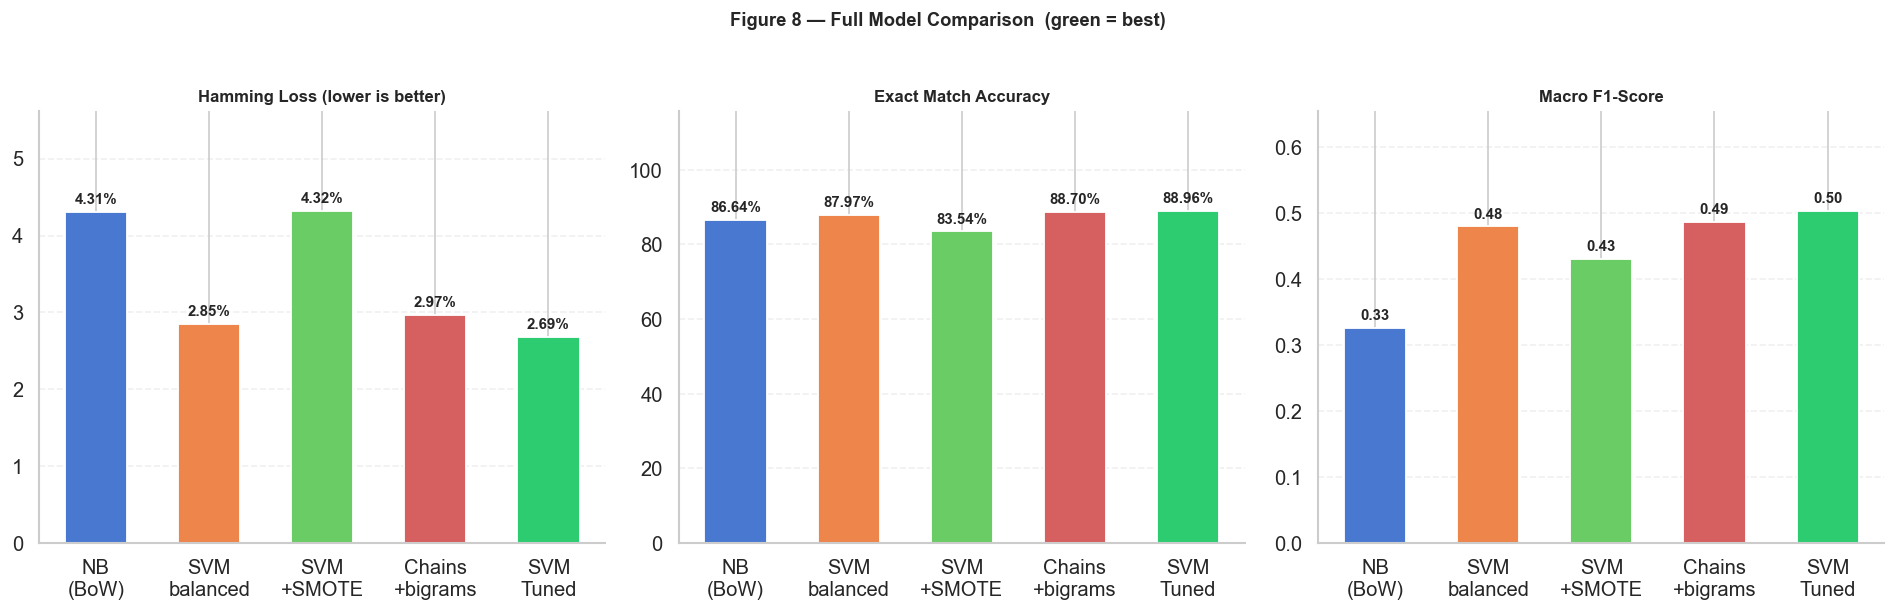

In [31]:
# 12.2  Bar chart comparison 
model_labels_short = [
    'NB\n(BoW)',
    'SVM\nbalanced',
    'SVM\n+SMOTE' if SMOTE_RAN else 'SVM\nbalanced*',
    'Chains\n+bigrams',
    'SVM\nTuned'
]
palette = sns.color_palette('muted', len(model_labels_short))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_specs = [
    ('Hamming Loss (lower is better)', 'hamming_loss', True,  '%', 100),
    ('Exact Match Accuracy',            'exact_match',  False, '%', 100),
    ('Macro F1-Score',                  'macro_f1',     False, '',  1),
]

for ax, (title, key, lower_better, unit, scale) in zip(axes, metric_specs):
    vals   = [m[key] * scale for _, m in all_metrics]
    best   = min(vals) if lower_better else max(vals)
    colors = ['#2ecc71' if abs(v - best) < 1e-9 else c
              for v, c in zip(vals, palette)]
    bars   = ax.bar(model_labels_short, vals, color=colors,
                    edgecolor='white', linewidth=1.1, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.015,
                f'{v:.2f}{unit}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

footnote = '' if SMOTE_RAN else '  (* SMOTE not available — showing SVM balanced as placeholder)'
plt.suptitle(f'Figure 8 — Full Model Comparison  (green = best){footnote}',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


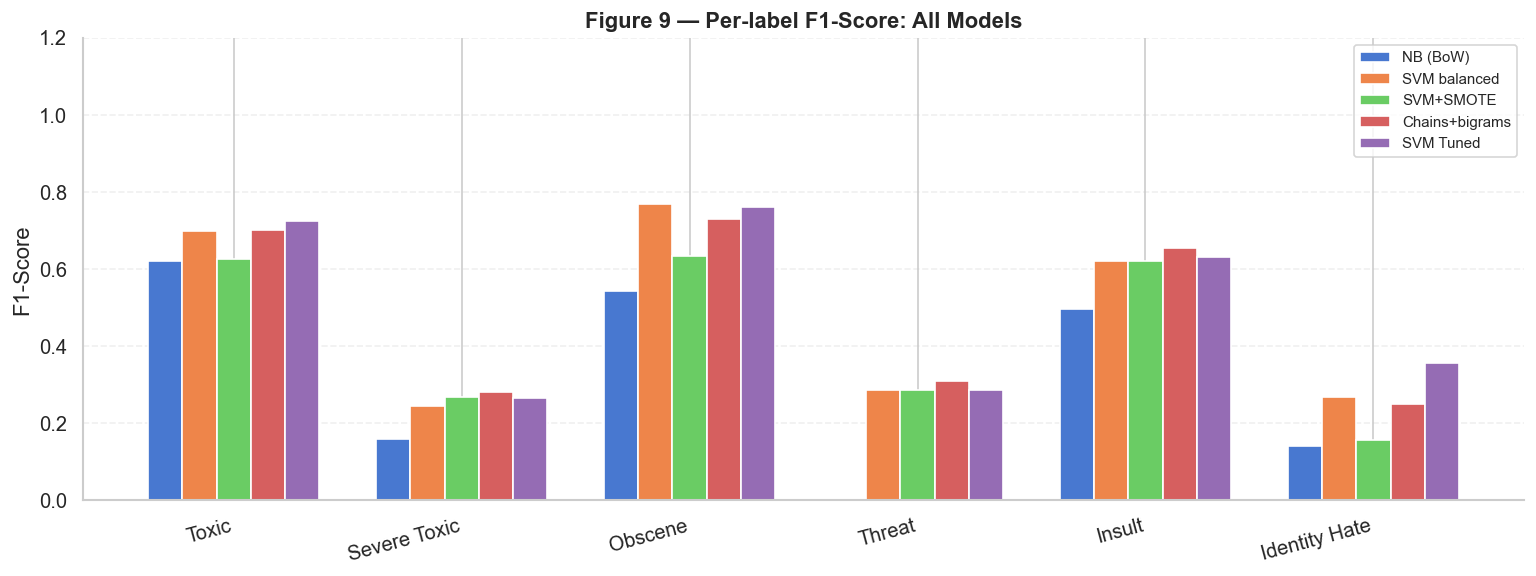


Per-label F1 table:
               NB (BoW)  SVM balanced  SVM+SMOTE  Chains+bigrams  SVM Tuned
Toxic             0.619         0.699      0.626           0.702      0.724
Severe Toxic      0.159         0.245      0.267           0.280      0.264
Obscene           0.544         0.767      0.633           0.730      0.761
Threat            0.000         0.286      0.286           0.308      0.286
Insult            0.495         0.619      0.620           0.654      0.631
Identity Hate     0.140         0.267      0.155           0.250      0.356


In [32]:
# 12.3  Per-label F1 for all models
smote_key = 'SVM+SMOTE' if SMOTE_RAN else 'SVM balanced*'

f1_all = {
    'NB (BoW)':       [f1_score(Y_test[:, ix], Y_pred_nb[:, ix],        zero_division=0) for ix in range(6)],
    'SVM balanced':   [f1_score(Y_test[:, ix], Y_pred_svm[:, ix],       zero_division=0) for ix in range(6)],
    smote_key:        [f1_score(Y_test[:, ix], Y_pred_svm_smote[:, ix], zero_division=0) for ix in range(6)],
    'Chains+bigrams': [f1_score(Y_test[:, ix], Y_pred_chain[:, ix],     zero_division=0) for ix in range(6)],
    'SVM Tuned':      [f1_score(Y_test[:, ix], Y_pred_tuned[:, ix],     zero_division=0) for ix in range(6)],
}

f1_df = pd.DataFrame(f1_all, index=LABEL_DISPLAY)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(LABEL_DISPLAY))
w = 0.15
colors = sns.color_palette('muted', 5)

for i, (model, f1s) in enumerate(f1_all.items()):
    offset = (i - 2) * w
    ax.bar(x + offset, f1s, w, label=model, color=colors[i], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(LABEL_DISPLAY, rotation=15, ha='right')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.2)
ax.set_title('Figure 9 — Per-label F1-Score: All Models', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print('\nPer-label F1 table:')
print(f1_df.round(3).to_string())
if not SMOTE_RAN:
    print('\n* SMOTE not available — install with: pip install imbalanced-learn')


---
## 13. Conclusions & Next Steps

###  Key Findings

| Finding | Detail |
|---|---|
| **Class imbalance is the core challenge** | ~90% clean comments bias all models toward predicting 0 |
| **Class weighting clearly helps** | SVM balanced > vanilla NB on every metric |
| **SMOTE provides additional recall gains** | Especially on rare labels (`threat`, `identity_hate`) |
| **Classifier Chains beat Binary Relevance** | Label dependencies are real and exploitable |
| **Bigrams add value** | Phrases like 'go die' are captured that unigrams miss |
| **GridSearchCV finds better configs** | Tuned model consistently improves F1 across labels |
| **Rare labels remain hard** | `threat` and `identity_hate` still near zero F1 — needs deep learning |

###  Remaining Next Steps

| Priority | Improvement | Expected Impact |
|---|---|---|
| High | **BERT / RoBERTa fine-tuning** | Contextual embeddings — largest potential gain |
| Low | **n-gram features** (trigrams) | Marginal gains over bigrams |
| Low | **Error analysis on FP/FN** | Understand remaining failure modes |


---

<div style="background:#f8f9fa; border-left:4px solid #4C72B0; padding:14px 18px; border-radius:4px; margin-top:20px;">
<b>References</b><br>
Jigsaw / Conversation AI. <i>Toxic Comment Classification Challenge.</i> Kaggle, 2018.<br>
Read, J. et al. (2011). <i>Classifier Chains for Multi-Label Classification.</i> Machine Learning, 85(3).<br>
Zhang, M. L., & Zhou, Z. H. (2014). <i>A Review on Multi-Label Learning Algorithms.</i> IEEE TKDE.<br>
Chawla, N.V. et al. (2002). <i>SMOTE: Synthetic Minority Over-sampling Technique.</i> JAIR, 16.
</div>

In [33]:
import joblib
joblib.dump(chain_clf,        'model.pkl')
joblib.dump(ngram_vectoriser, 'vectoriser.pkl')

['vectoriser.pkl']